### __Router__
__Review__
We built a graph that uses `messages` as state and a chat model with bound tools.

We saw that the graph can:

* Return a tool call
* Return a natural language response

__Objective :__

We can think of this as a router, where the _chat model routes_ between a `direct response` or a `tool call based` upon the user input.

This is a simple example of an agent, where the LLM is directing the control flow either by calling a tool or just responding directly.

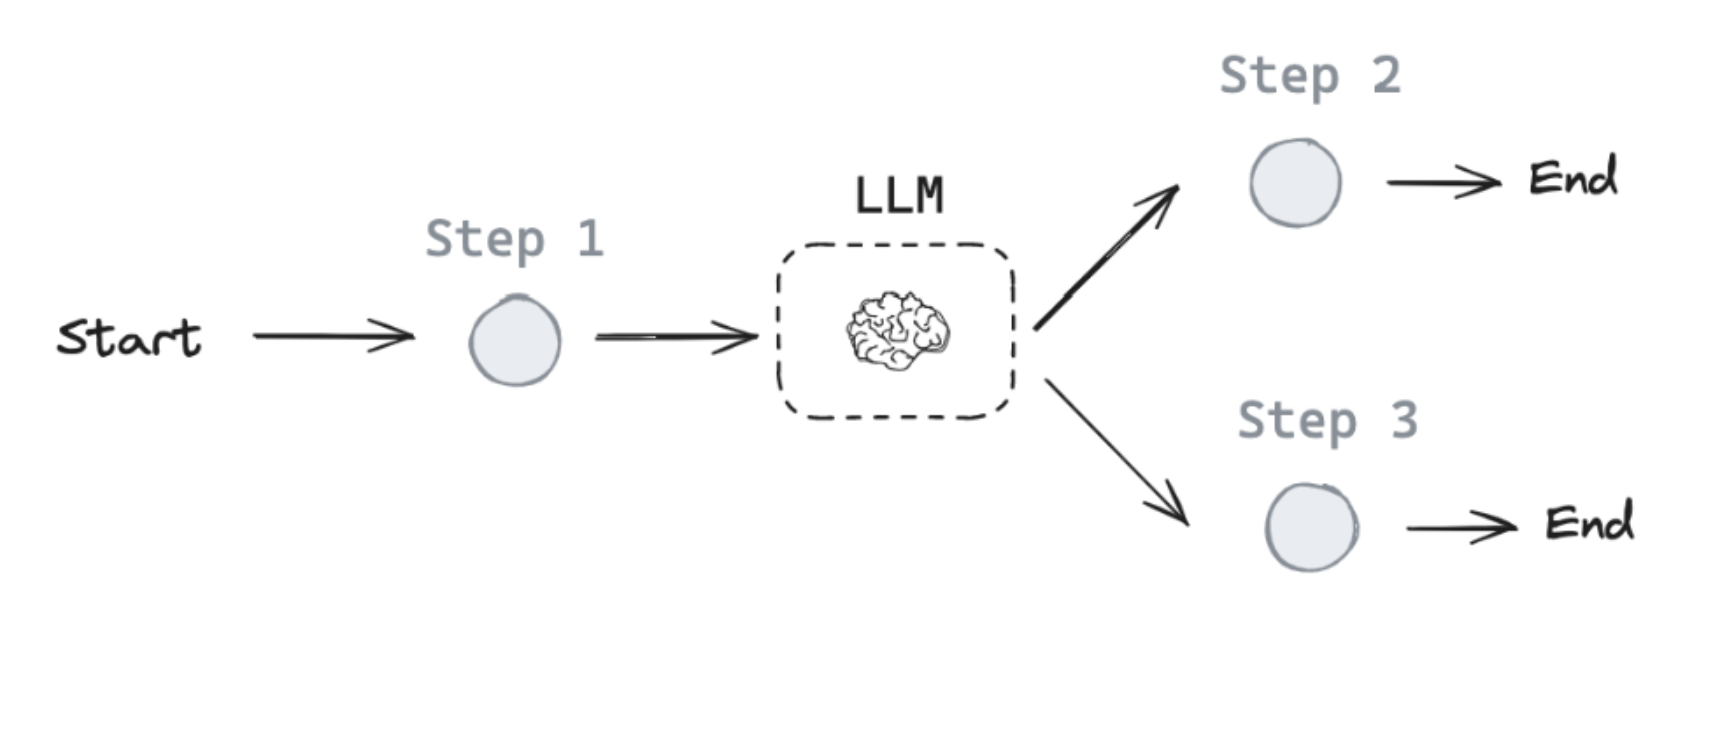

Let's extend our graph to work with either output!

For this, we can use two ideas:

(1) Add a `node` that will call our `tool`.

(2) Add a `conditional edge` that will look at the `chat model output`, and route to our `tool calling node` or simply `end` if no tool call is performed.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
NV_API_KEY = os.getenv("NV_API_KEY")
NV_API_URL = os.getenv("NV_API_URL")

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    openai_api_key=NV_API_KEY,
    openai_api_base=NV_API_URL,
    temperature=0.001,
    top_p=1,
    max_tokens=4096,
    streaming=False,
    extra_body={"reasoning_effort": "low"}
)

In [2]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b
llm_with_tools = llm.bind_tools([multiply])

We use the `built-in ToolNode` and simply pass a list of our tools to __initialize__ it.

We use the `built-in tools_condition` as our __conditional edge__.

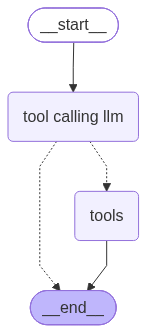

In [3]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool calling llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool calling llm")
builder.add_conditional_edges(
    "tool calling llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-aedb8aabbffc7dea)
 Call ID: chatcmpl-tool-aedb8aabbffc7dea
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4


[Local development server](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server)

1. Install the LangGraph CLI\
pip install -U "langgraph-cli[inmem]"\
langgraph dev

2. This will start the Agent Server locally, running in-memory. The server will run in watch mode, listening for and automatically restarting on code changes.

3. For a running server, access the Dbugger with one of the following:
* Directly navigate to the following URL: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024.
* Navigate to Deployments in the UI, click the Studio button on a deployment, enter http://127.0.0.1:2024 and click Connect.\
If running your server at a different host or port, update the baseUrl to match.

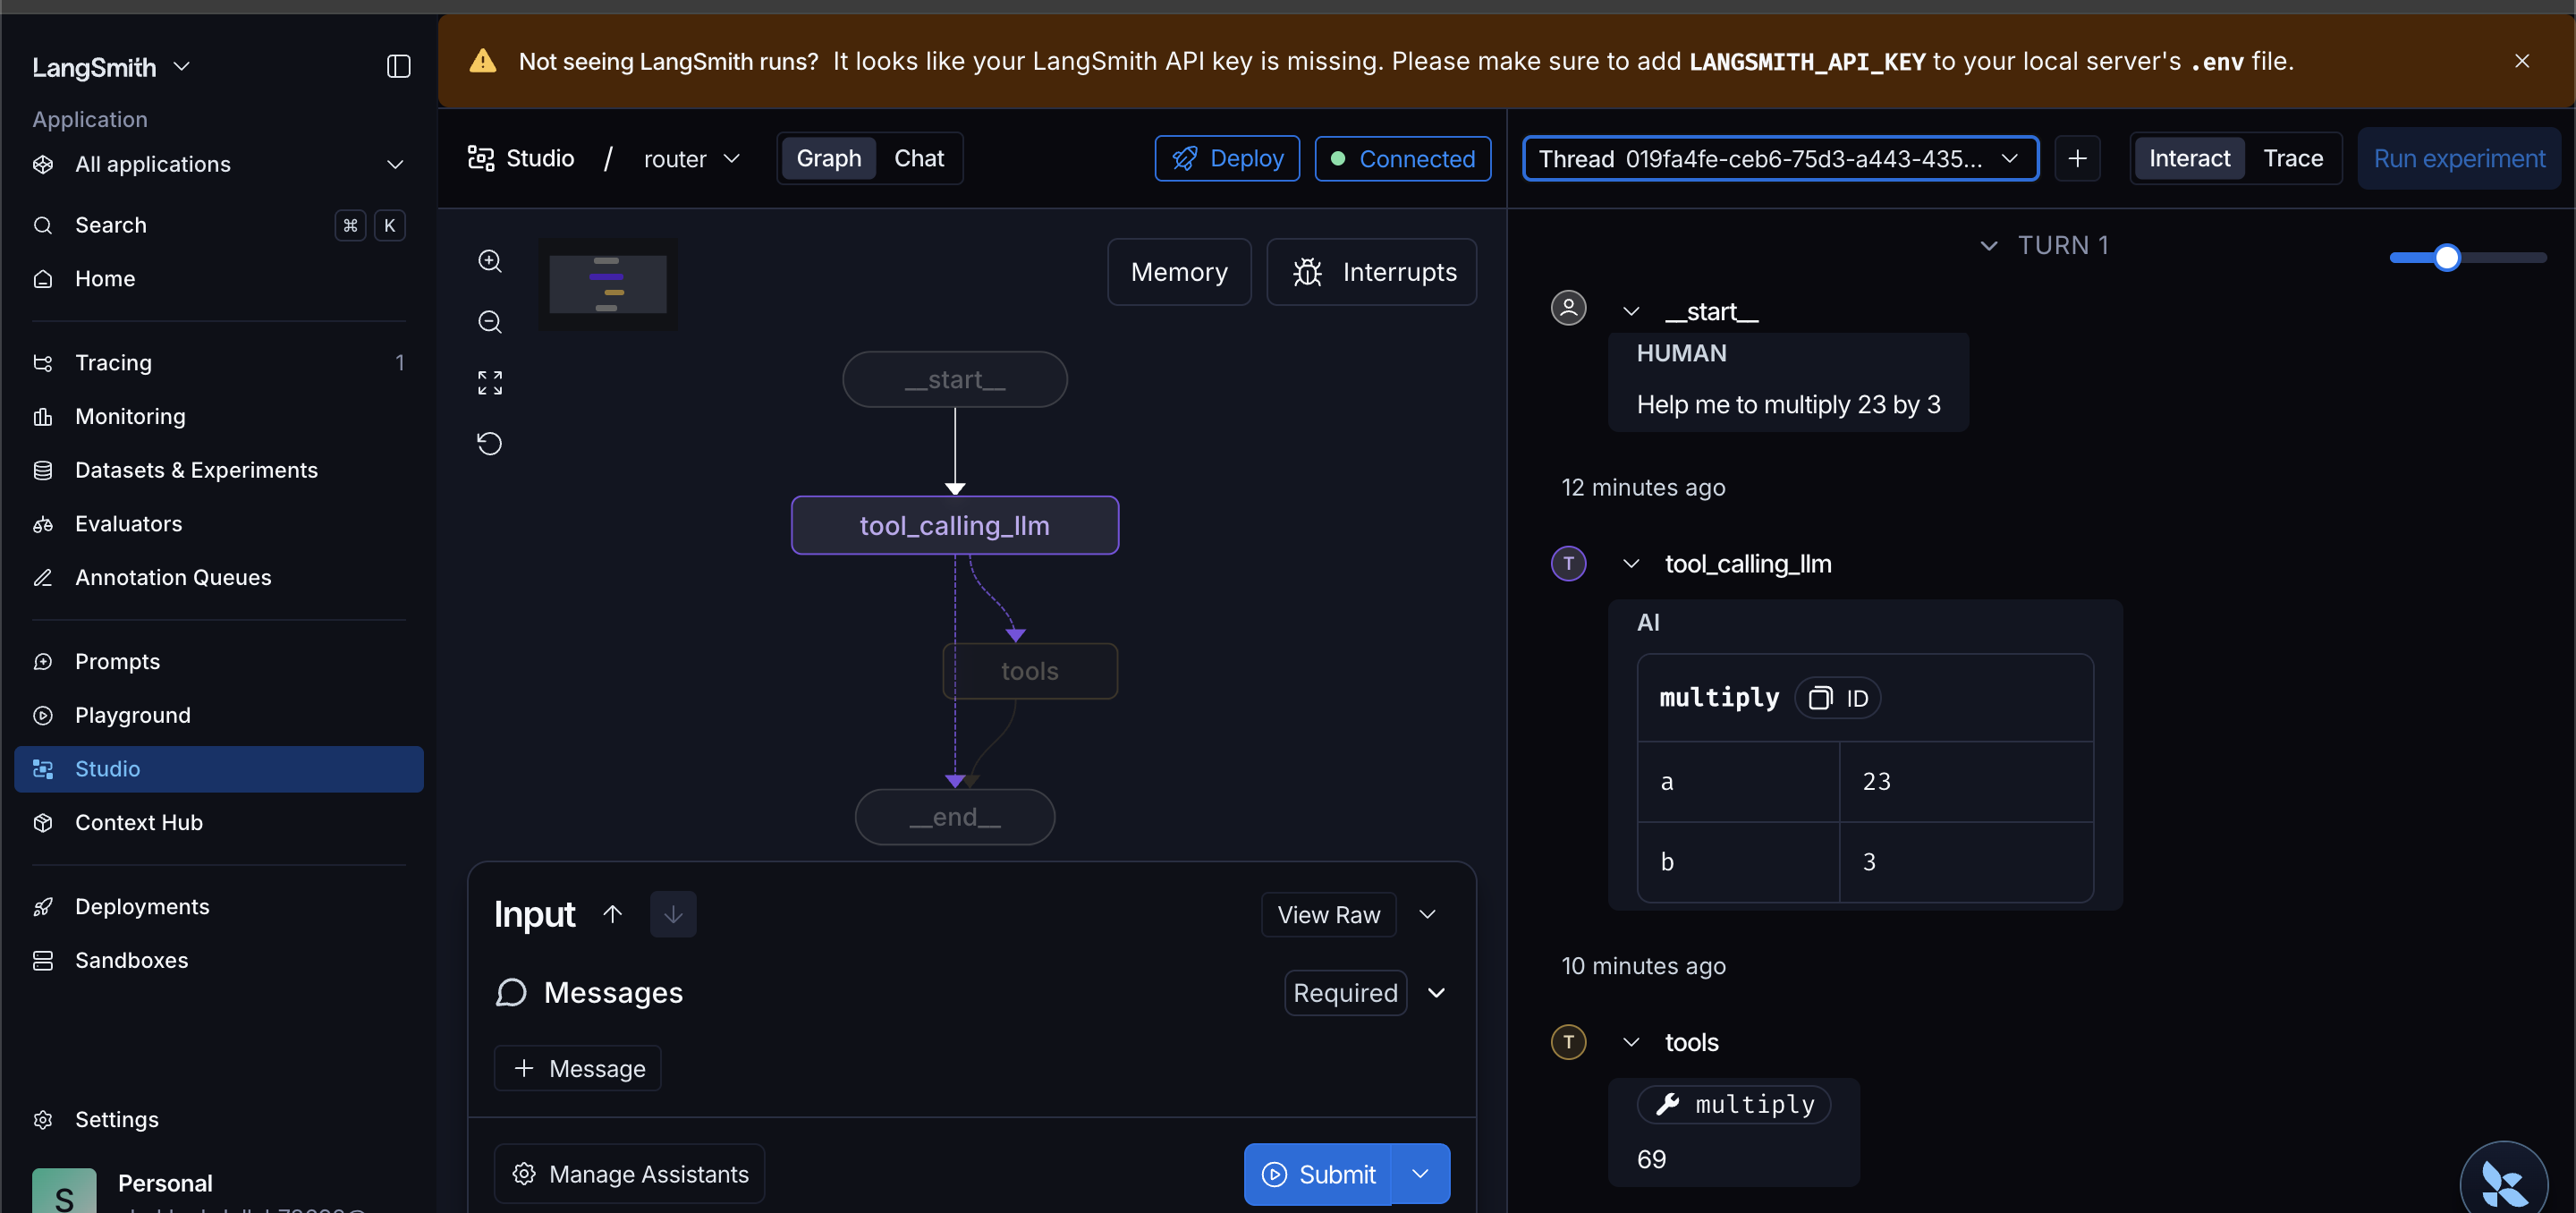